<a href="https://colab.research.google.com/github/ryukf333/fruit-freshness-ai/blob/main/02Machine_Learning_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define directory paths
DRIVE_ROOT = Path('/content/drive/MyDrive/fruit_freshness_project')
local_raw = Path('/content/dataset_raw')

# 3. Locate zip file on Drive and extract to Colab's local SSD
zip_files = list((DRIVE_ROOT / 'data/raw').glob('*.zip'))
if not zip_files:
    raise FileNotFoundError("Could not find any .zip file in fruit_freshness_project/data/raw/")

zip_path = zip_files[0]
print(f"Unpacking {zip_path.name} to {local_raw}...")

with zipfile.ZipFile(zip_path, 'r') as archive:
    archive.extractall(local_raw)

print("Unpack complete! Images are restored on local SSD.")

# 4. Reload saved splits from Google Drive
splits_dir = DRIVE_ROOT / 'data/processed'
df_train = pd.read_csv(splits_dir / 'train_manifest.csv')
df_val   = pd.read_csv(splits_dir / 'val_manifest.csv')
df_test  = pd.read_csv(splits_dir / 'test_manifest.csv')

# 5. Sanity check: verify that the first image path exists on disk
sample_file = Path(df_train.iloc[0]['file_path'])
print(f"\nVerification check:")
print(f"  • File path: {sample_file}")
print(f"  • Exists on disk: {sample_file.exists()}")
print(f"  • Training set size: {len(df_train):,} samples")
print(f"  • Validation set size: {len(df_val):,} samples")

Mounted at /content/drive
Unpacking AgriFreshNET.zip to /content/dataset_raw...
Unpack complete! Images are restored on local SSD.

Verification check:
  • File path: /content/dataset_raw/Processed Data/Semi fresh Orange(9-20)/IMG_20251125_185750037_HDR.jpg
  • Exists on disk: True
  • Training set size: 9,884 samples
  • Validation set size: 2,118 samples


In [ ]:
def extract_classical_features(image_path: str) -> np.ndarray:
    """
    Extracts a 22-dimensional feature vector from a single image:
      - 6 HSV color moments (mean, std for H, S, V)
      - 6 Lab color moments (mean, std for L, a, b)
      - 10 LBP texture histogram bins
    """
    # 1. Read image with OpenCV (BGR)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not load image at {image_path}")

    # Resize to standard dimensions (128x128 is fast and sufficient for global statistics)
    img_bgr = cv2.resize(img_bgr, (128, 128))

    # 2. Color Space Conversions
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 3. Compute Color Moments (Mean & Standard Deviation)
    # HSV moments
    h_mean, h_std = np.mean(img_hsv[:, :, 0]), np.std(img_hsv[:, :, 0])
    s_mean, s_std = np.mean(img_hsv[:, :, 1]), np.std(img_hsv[:, :, 1])
    v_mean, v_std = np.mean(img_hsv[:, :, 2]), np.std(img_hsv[:, :, 2])

    # Lab moments
    l_mean, l_std = np.mean(img_lab[:, :, 0]), np.std(img_lab[:, :, 0])
    a_mean, a_std = np.mean(img_lab[:, :, 1]), np.std(img_lab[:, :, 1])
    b_mean, b_std = np.mean(img_lab[:, :, 2]), np.std(img_lab[:, :, 2])

    color_features = [
        h_mean, h_std, s_mean, s_std, v_mean, v_std,
        l_mean, l_std, a_mean, a_std, b_mean, b_std
    ]

    # 4. Compute Uniform Local Binary Patterns (LBP)
    # P=8 neighbors, R=1 radius. Uniform method outputs P + 2 = 10 bins.
    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)

    # 5. Concatenate all features into a 1D vector (12 + 10 = 22 dimensions)
    return np.hstack([color_features, lbp_hist])

In [ ]:
# Numerical label mapping: Fresh -> 0, Semi-Fresh -> 1, Rotten -> 2
label_mapping = {'Fresh': 0, 'Semi-Fresh': 1, 'Rotten': 2}

def process_dataset(df: pd.DataFrame):
    X = []
    y = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
        try:
            feats = extract_classical_features(row['file_path'])
            X.append(feats)
            y.append(label_mapping[row['freshness_label']])
        except Exception as e:
            print(f"Skipping corrupt/missing item {row['file_path']}: {e}")
            continue

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Processing Training Set...")
X_train, y_train = process_dataset(df_train)

print("\nProcessing Validation Set...")
X_val, y_val = process_dataset(df_val)

print(f"\nFeature matrix shapes:")
print(f"  • X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  • X_val:   {X_val.shape}   | y_val:   {y_val.shape}")

Processing Training Set...


Extracting features: 100%|██████████| 9884/9884 [01:23<00:00, 118.42it/s]



Processing Validation Set...


Extracting features: 100%|██████████| 2118/2118 [00:16<00:00, 127.12it/s]


Feature matrix shapes:
  • X_train: (9884, 22) | y_train: (9884,)
  • X_val:   (2118, 22)   | y_val:   (2118,)


Training Random Forest baseline on classical features...

       CLASSICAL BASELINE (RANDOM FOREST) RESULTS
              precision    recall  f1-score   support

       Fresh     0.8569    0.8909    0.8736       706
  Semi-Fresh     0.8338    0.8148    0.8242       702
      Rotten     0.9054    0.8901    0.8977       710

    accuracy                         0.8654      2118
   macro avg     0.8654    0.8653    0.8652      2118
weighted avg     0.8655    0.8654    0.8653      2118



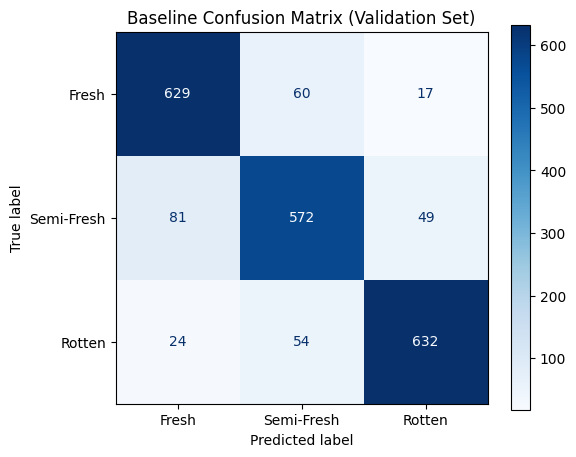

In [ ]:
# Initialize and fit Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest baseline on classical features...")
rf_baseline.fit(X_train, y_train)

# Evaluate on Validation Split
y_val_pred = rf_baseline.predict(X_val)

target_names = ['Fresh', 'Semi-Fresh', 'Rotten']

# 1. Print Detailed Classification Report
print("\n" + "="*50)
print("       CLASSICAL BASELINE (RANDOM FOREST) RESULTS")
print("="*50)
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# 2. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Baseline Confusion Matrix (Validation Set)")
plt.show()